In [100]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Compute cosine similarity matrix between all gradient results
import torch.nn.functional as F

In [101]:
def compute_cosine_similarity_matrix(results):
    """Compute pairwise cosine similarity matrix for gradient results."""
    n = len(results)
    cosine_sim_matrix = torch.zeros(n, n)

    # Compute cosine similarity for each pair (only upper triangle since it's symmetric)
    for i in range(n):
        for j in range(i, n):
            grad_i = results[i].gradient
            grad_j = results[j].gradient

            # Compute cosine similarity
            cos_sim = F.cosine_similarity(grad_i.unsqueeze(0),
                                          grad_j.unsqueeze(0)).item()

            # Fill both (i,j) and (j,i) since matrix is symmetric
            cosine_sim_matrix[i, j] = cos_sim
            cosine_sim_matrix[j, i] = cos_sim

    return cosine_sim_matrix


def compute_success(df_data,
                    threshold_angle=0.1,
                    consecutive_steps=100,
                    starting_step=0,
                    column_name=None):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column
    """
    success = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])
        observations = observations[starting_step:]

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)
    column_name = column_name if column_name is not None else 'success'
    df_data[column_name] = np.array(success)
    return df_data

In [103]:
def load_data(
    df_metadata,
    cart_position=None,
    pole_angle=None,
    normalization_method=None,
    seed=None,
):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    cart_position_list = to_list(cart_position)
    pole_angle_list = to_list(pole_angle)
    seed_list = to_list(seed)
    normalization_list = to_list(normalization_method)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        inital_state = config.get('initial_state')
        # Check each criterion
        if cart_position_list is not None and inital_state[
                0] not in cart_position_list:
            continue
        if pole_angle_list is not None and inital_state[
                1] not in pole_angle_list:
            continue
        if normalization_list is not None and config.get(
                'normalization_method') not in normalization_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def load_sweep_metadata(sweep_base_dirs):
    """
    Load and flatten metadata from one or more sweep base directories.

    Args:
        sweep_base_dirs: Path or list of Path objects/strings

    Returns:
        pd.DataFrame with flattened metadata for all runs in all provided directories
    """
    from tqdm import tqdm

    if isinstance(sweep_base_dirs, (str, Path)):
        sweep_base_dirs = [sweep_base_dirs]
    sweep_base_dirs = [Path(d) for d in sweep_base_dirs]

    all_metadata = []
    for sweep_base_dir in sweep_base_dirs:
        sweep_dirs = [d for d in sweep_base_dir.iterdir() if d.is_dir()]
        for sweep_dir in tqdm(sweep_dirs, desc=f"Dirs in {sweep_base_dir}"):
            metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
            if metadata_path.exists():
                with open(metadata_path, 'r') as f:
                    try:
                        metadata = json.load(f)
                        # Flatten the nested metadata dictionary
                        flattened_metadata = flatten_dict(metadata)
                        # Add the directory path
                        flattened_metadata['directory'] = str(sweep_dir)
                        all_metadata.append(flattened_metadata)
                    except json.JSONDecodeError:
                        print(f"Error decoding JSON for {metadata_path}")
                        continue

    print(f"Found {len(all_metadata)} configurations")
    # Create DataFrame from flattened metadata
    df_metadata = pd.DataFrame(all_metadata)
    return df_metadata


In [104]:
# df_metadata_spsa = load_sweep_metadata([
#     "logs/25-12-03-spsa-position",
# ])

df_metadata_probing = load_sweep_metadata(
    ["logs/25-12-04-latent_intervention_control_sweep"])


Dirs in logs/25-12-04-latent_intervention_control_sweep: 100%|██████████| 704/704 [00:04<00:00, 147.77it/s]

Found 704 configurations


In [107]:
df_metadata_lasso = df_metadata_probing[
    df_metadata_probing['config_direction_str'] == 'w_action_lasso']

In [110]:
df_metadata_lasso['config_lasso_alpha'].value_counts()

config_lasso_alpha
0.0010    88
0.0000    88
0.0050    88
0.0001    88
Name: count, dtype: int64

In [112]:
df = load_data(df_metadata_lasso)

Found 352 configurations


100%|██████████| 352/352 [00:04<00:00, 82.14it/s]


In [113]:
dim_names = {
    0: 'Cart Position',
    1: 'cos(Pole Angle)',
    2: 'sin(Pole Angle)',
    3: 'Cart Velocity',
    4: 'Pole Angular Velocity',
}

In [133]:
df = compute_success(df, starting_step=100, consecutive_steps=300)

In [120]:
df['config_hinge_1_value_degrees'] = np.degrees(df['config_hinge_1_value'])
df['hinge_str'] = df['config_hinge_1_value_degrees'].round(0).astype(str)

for dim in range(5):
    df[f'average_dim_{dim}'] = df['observations'].apply(
        lambda x: np.mean(np.array(x)[:, dim]))

In [121]:
df['total_position_change'] = df['observations'].apply(
    lambda x: np.array(x)[-1, 0] - np.array(x)[0, 0])

In [122]:
df['cumulative_abs_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

df['cumulative_position_change'] = df['observations'].apply(
    lambda x: np.sum(np.diff(np.array(x)[:, 0])))

## General overview

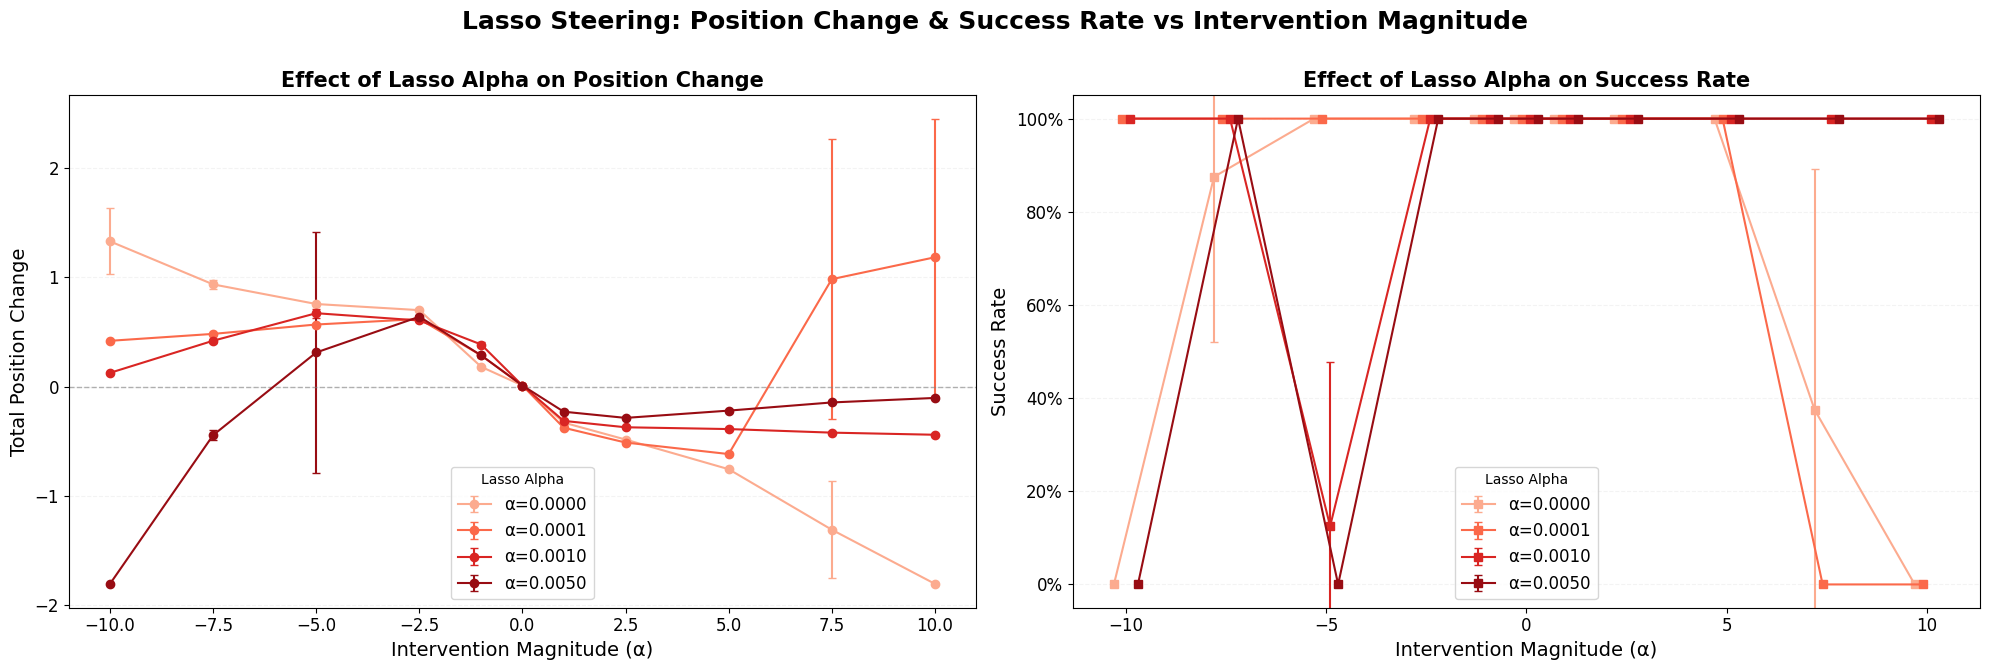

In [134]:
import matplotlib.ticker as mticker
import numpy as np

# Sort and prepare unique lasso_alphas
lasso_alphas = sorted(df['config_lasso_alpha'].unique())

# Use reds colormap based on the number of alphas
reds_cmap = plt.get_cmap("Reds")
colors = [
    reds_cmap(0.3 + 0.6 * (i / max(len(lasso_alphas) - 1, 1)))
    for i in range(len(lasso_alphas))
]
alpha_to_color = dict(zip(lasso_alphas, colors))

# ----------- Side-by-side plots --------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7), sharex=False)

# --- Plot 1: Total Position Change vs Magnitude ---
for idx, lasso_alpha in enumerate(lasso_alphas):
    d = df[df['config_lasso_alpha'] == lasso_alpha]
    d_sorted = d.sort_values('config_magnitude')
    group = d_sorted.groupby('config_magnitude')
    alpha_for_label = f"{lasso_alpha:.4f}" if isinstance(
        lasso_alpha, float) else str(lasso_alpha)
    pos_mean = group['total_position_change'].mean()
    pos_std = group['total_position_change'].std()
    magnitude_vals = pos_mean.index.values
    ax1.errorbar(
        magnitude_vals,
        pos_mean,
        yerr=pos_std,
        color=alpha_to_color[lasso_alpha],
        marker='o',
        linestyle='-',
        capsize=3,
        label=f'α={alpha_for_label}',
    )

ax1.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax1.set_xlabel("Intervention Magnitude (α)", fontsize=14)
ax1.set_ylabel("Total Position Change", fontsize=14)
ax1.tick_params(axis='both', labelsize=12)
ax1.legend(title="Lasso Alpha", fontsize=12, frameon=True)
ax1.grid(True, which='major', axis='y', alpha=0.15, linestyle='--')
ax1.set_axisbelow(True)
ax1.set_title("Effect of Lasso Alpha on Position Change",
              fontsize=15,
              weight='bold')

# --- Plot 2: Success Rate vs Magnitude (with jitter) ---
# Amount by which to jitter the x-axis for separation
jitter_amt = 0.2 if len(lasso_alphas) > 1 else 0
for idx, lasso_alpha in enumerate(lasso_alphas):
    d = df[df['config_lasso_alpha'] == lasso_alpha]
    d_sorted = d.sort_values('config_magnitude')
    group = d_sorted.groupby('config_magnitude')
    alpha_for_label = f"{lasso_alpha:.4f}" if isinstance(
        lasso_alpha, float) else str(lasso_alpha)
    magnitude_vals = group['success'].mean().index.values
    # jitter each line's x positions
    x_jittered = magnitude_vals + (idx -
                                   (len(lasso_alphas) - 1) / 2) * jitter_amt

    success_mean = group['success'].mean()
    success_std = group['success'].std()
    ax2.errorbar(
        x_jittered,
        success_mean,
        yerr=success_std,
        color=alpha_to_color[lasso_alpha],
        marker='s',
        linestyle='-',
        capsize=3,
        label=f'α={alpha_for_label}',
    )

ax2.set_xlabel("Intervention Magnitude (α)", fontsize=14)
ax2.set_ylabel("Success Rate", fontsize=14)
ax2.set_ylim(-0.05, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax2.tick_params(axis='both', labelsize=12)
ax2.legend(title="Lasso Alpha", fontsize=12, frameon=True)
ax2.grid(True, which='major', axis='y', alpha=0.15, linestyle='--')
ax2.set_axisbelow(True)
ax2.set_title("Effect of Lasso Alpha on Success Rate",
              fontsize=15,
              weight='bold')

fig.suptitle(
    "Lasso Steering: Position Change & Success Rate vs Intervention Magnitude",
    fontsize=18,
    weight='bold')
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


/scratch/slurm_tmpdir/job_1591623/ipykernel_1685428/1503055499.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values,


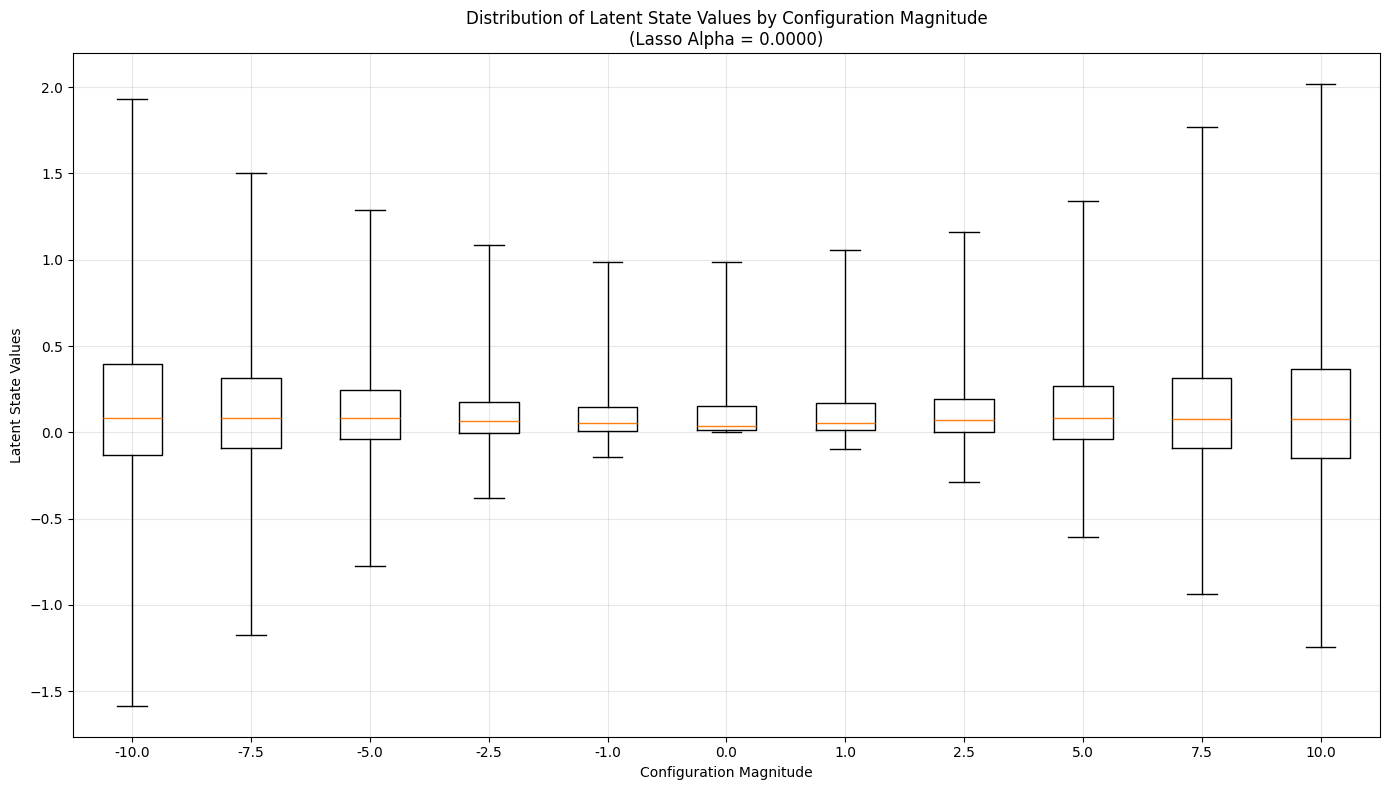

/scratch/slurm_tmpdir/job_1591623/ipykernel_1685428/1503055499.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values,


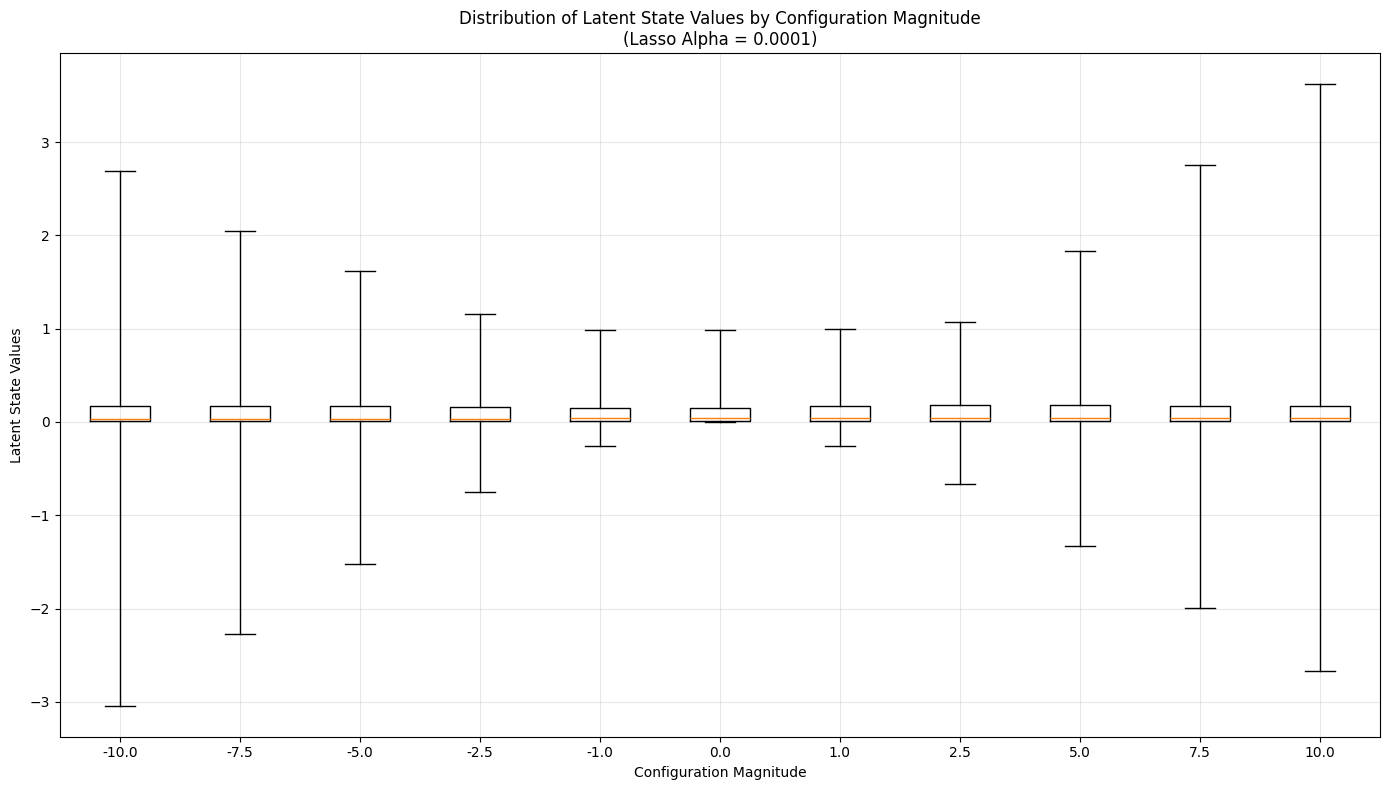

/scratch/slurm_tmpdir/job_1591623/ipykernel_1685428/1503055499.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values,


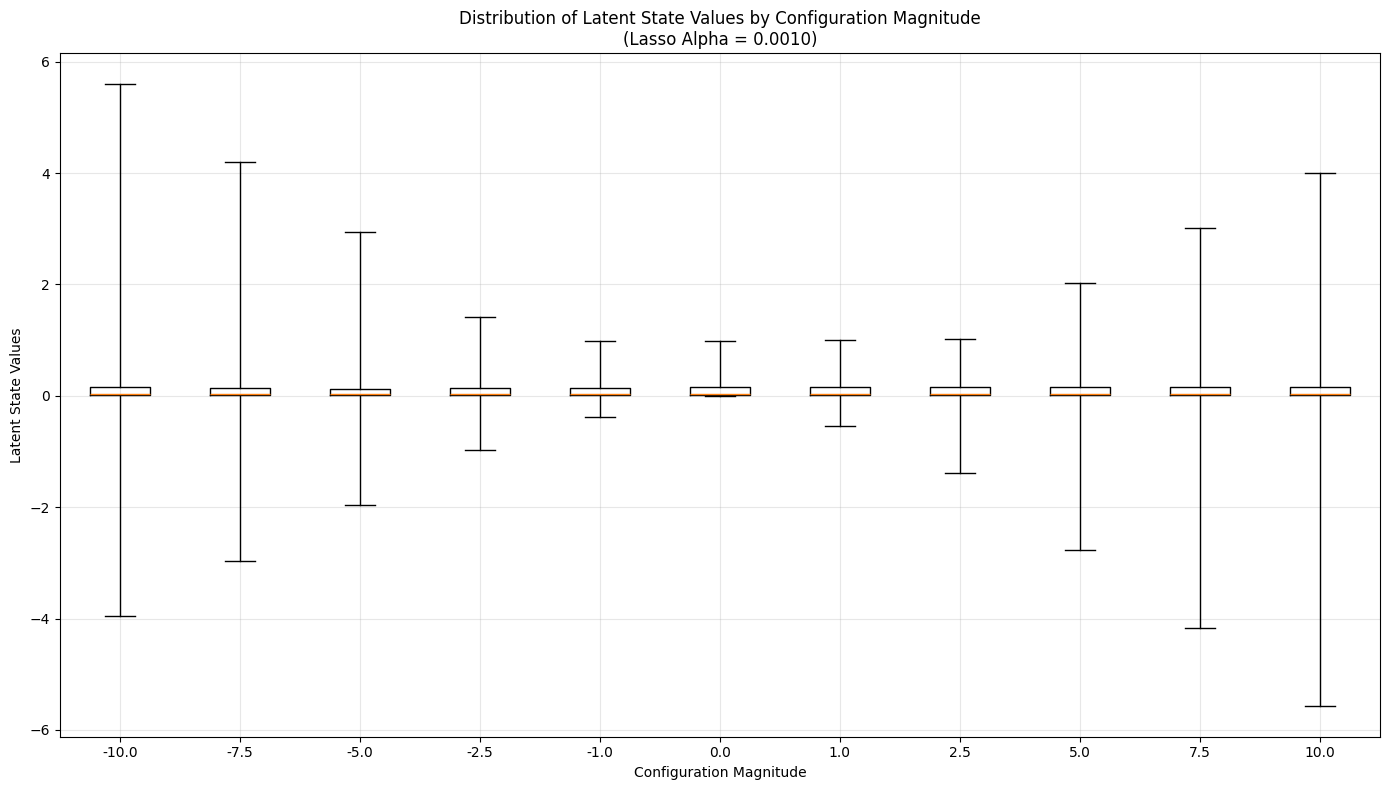

/scratch/slurm_tmpdir/job_1591623/ipykernel_1685428/1503055499.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values,


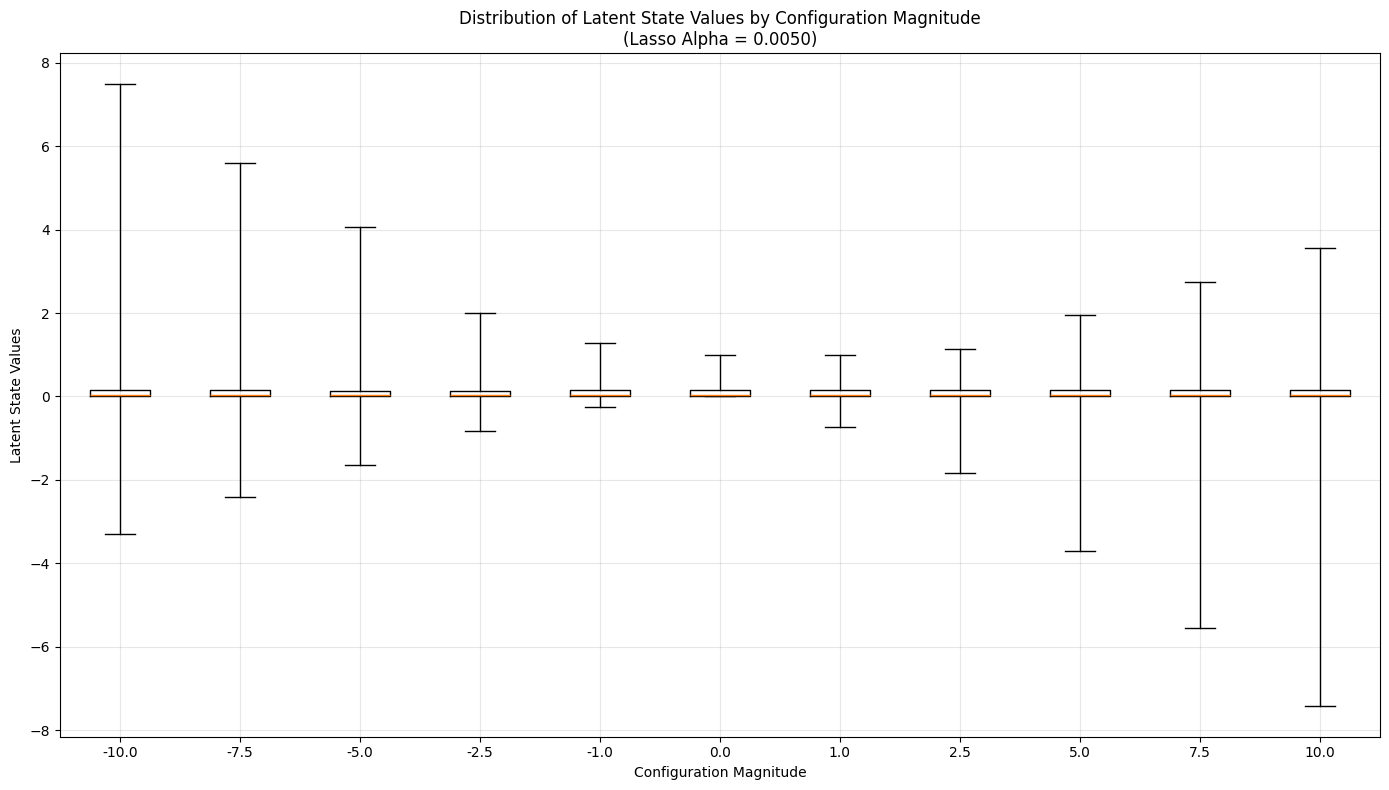

In [135]:
# Plot a boxplot of latent state values by magnitude, one plot for each lasso alpha
lasso_alphas_sorted = sorted(df['config_lasso_alpha'].unique())
magnitudes = sorted(df['config_magnitude'].unique())

for lasso_alpha in lasso_alphas_sorted:
    df_alpha = df[df['config_lasso_alpha'] == lasso_alpha]
    all_latent_values = []

    for magnitude in magnitudes:
        # Get all latent states for this magnitude and lasso_alpha
        latent_states = df_alpha[df_alpha['config_magnitude'] ==
                                 magnitude]['latent_states']

        # Flatten all latent states into a single list
        flattened = []
        for episode_latents in latent_states:
            flattened.extend(episode_latents.flatten())

        all_latent_values.append(flattened)

    plt.figure(figsize=(14, 8))
    plt.boxplot(all_latent_values,
                labels=magnitudes,
                showfliers=False,
                whis=[0, 100])
    plt.xlabel('Configuration Magnitude')
    plt.ylabel('Latent State Values')
    plt.title(
        f'Distribution of Latent State Values by Configuration Magnitude\n(Lasso Alpha = {lasso_alpha:.4f})'
    )
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
